<a href="https://colab.research.google.com/github/Lanaalkhammash/final_project_Titanic1/blob/main/02_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


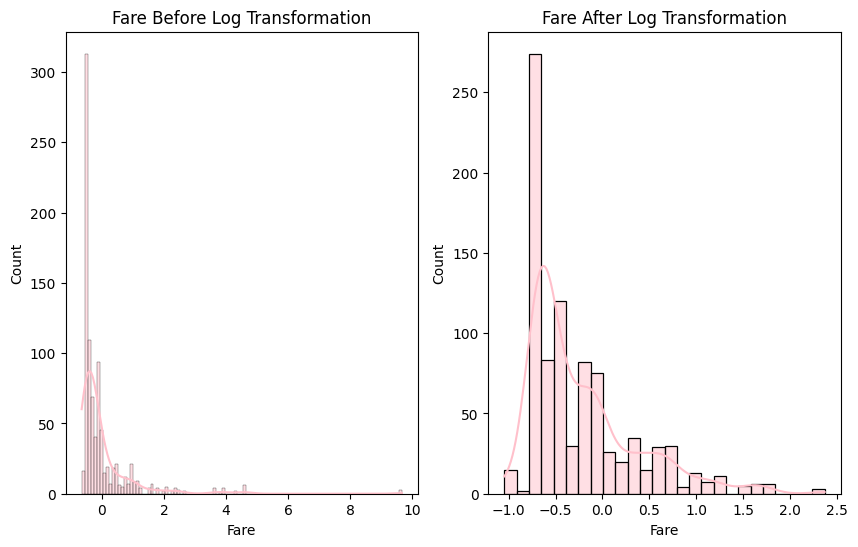

        Age Age_Group
0 -0.530377       NaN
1  0.571831     Child
2 -0.254825       NaN
3  0.365167     Child
4  0.365167     Child
The deleted columns are:[]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

#Load the cleaned dataset from the previous phase
df = pd.read_csv('/content/cleaned_data (1).csv')
print(df.head())
#Apply One-hot Encoding to nominal categorical variables (Sex and Embarked)
df = pd.get_dummies(df, columns=['Sex', 'Embarked'],drop_first=True)
#Perform Ordinal Encoding on 'Pclass' to preserve the inherent ranking
# كنت بسوي له ordinal encoding لكن اكتشفت انه ليس بحاجته
df['Pclass'] = df['Pclass'].astype(int)
#Standardize numerical features (Age and Fare) using StandardScaler
scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

#Apply Log-Transformation to 'Fare' to mitigate skewness and normalize distribution
plt.figure(figsize=(10, 6))
plt.subplot(1,2,1)
sns.histplot(df['Fare'], kde=True, color='pink')
plt.title('Fare Before Log Transformation')

plt.subplot(1,2,2)
df['Fare'] = np.log1p(df['Fare'])
sns.histplot(df['Fare'], kde=True, color='pink')
plt.title('Fare After Log Transformation')
plt.show()


#Create a 'Family_Size' feature as a domain-specific ratio/sum
df['Fare_per_person']=df['Fare']/(df['SibSp']+df['Parch']+1)
#Generate an Interaction Feature between 'Age' and 'Pclass'
df['Age_calss_Interaction']= df['Age']* df['Pclass']


survival_rate_by_sex = df.groupby('Sex_male')['Survived'].mean()
df['Sex_Survival_Rate'] = df['Sex_male'].map(survival_rate_by_sex)



#Implement Binning on 'Age' to transform continuous data into categorical groups
bins=[0,12,18,60,100]
labels=['Child','Teenager','Adult','Senior']
df['Age_Group']=pd.cut(df['Age'],bins=bins,labels=labels)
print(df[['Age','Age_Group']].head())

#Identify and remove redundant features with a correlation coefficient exceeding 0.95
df_numeric = df.drop(columns=['Name', 'Ticket', 'Cabin', 'Age_Group'], errors='ignore')
corr = df_numeric.corr()

colums_to_drop=set()
for i in range(len(corr.columns)):
  for j in range(i):
    if corr.iloc[i,j]>0.95:
      col_name=corr.columns[i]
      colums_to_drop.add(col_name)
df = df.drop(columns=colums_to_drop)

print(f"The deleted columns are:{list(colums_to_drop)}")


#Export the final engineered features for the next phase
df.to_csv('engineered_data.csv',index=False)

from google.colab import files
files.download('engineered_data.csv')